# ☕ Pipeline Predictivo Interactivo — Cultivo de Café en Colombia

Este cuaderno ejecuta **paso a paso** todo el pipeline de predicción de rendimiento y rentabilidad del café.

### Flujo del Pipeline
```
dataset_cafe_ml_ready.csv  (datos ETL procesados)
        │
        ├── ETL v3 Normalización (Z-score features, preserva IDs)
        ├── Evaluación Baselines (heurísticas lag-1, media 3y)
        ├── Entrenamiento CatBoost + Ablation Study (6 fases A-F)
        ├── Gráficas comparativas (MAE, Feature Importance)
        ├── Análisis de Rentabilidad
        └── Forecast 2025-2029 + Probabilidad de Éxito
```

> 📄 **Origen de los datos:** El archivo `dataset_cafe_ml_ready.csv` fue construido mediante un proceso ETL de dos pasos documentado en:
> - `docs/03_ETL_CAFE_SIN_LEAKAGE_step_1.md` — Extracción y limpieza sin data leakage
> - `docs/04_ETL_EXPLICACION_step_2.md` — Feature engineering y preparación ML-ready

---
## 1. 📦 Instalación de Dependencias
Ejecutar solo si estás en **Google Colab** o un entorno limpio.

In [1]:
# Descomentar la siguiente línea si estás en Google Colab
# !pip install pandas numpy catboost scikit-learn matplotlib seaborn pyyaml shap tqdm openpyxl -q

## 2. 🔧 Importaciones y Configuración del Proyecto

In [2]:
import os
import sys
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import yaml
import warnings
warnings.filterwarnings('ignore')

# Cargar configuración del proyecto
with open('config/config.yaml', 'r', encoding='utf-8') as f:
    config = yaml.safe_load(f)

cultivo = config['project'].get('cultivo_mvp', 'cafe')
print(f'📌 Cultivo MVP configurado: {cultivo.upper()}')
print(f'📅 Años de backtest: {config["project"].get("años_backtest", [2019,2020,2021,2022,2023,2024])}')

📌 Cultivo MVP configurado: CAFE
📅 Años de backtest: [2019, 2020, 2021, 2022, 2023, 2024]


## 3. 📊 Exploración del Dataset de Entrenamiento

El archivo `dataset_cafe_ml_ready.csv` contiene **10,973 filas × 48 columnas** con datos históricos (2007-2024) de rendimiento de café por municipio, incluyendo:
- **Lags temporales** (rendimiento años anteriores)
- **Variables de suelo** (pH, materia orgánica, fósforo, etc.)
- **Variables de crédito** (FINAGRO)
- **Indicadores de calidad** (score de confiabilidad)

In [3]:
# Cargar el dataset REAL de entrenamiento
DATA_PATH = 'reports/tablas_entrenamiento/dataset_cafe_ml_ready.csv'
df = pd.read_csv(DATA_PATH)

print(f'📐 Dimensiones: {df.shape[0]:,} filas × {df.shape[1]} columnas')
print(f'📅 Rango temporal: {df["anio"].min()} - {df["anio"].max()}')
print(f'🗺️  Municipios únicos: {df["municipio"].nunique()}')
print(f'🏔️  Departamentos: {df["departamento"].nunique()}')
print(f'\n--- Distribución por split ---')
print(df['split'].value_counts())
print(f'\n--- Primeras filas ---')
display(df.head())

📐 Dimensiones: 10,973 filas × 48 columnas
📅 Rango temporal: 2007 - 2024
🗺️  Municipios únicos: 641
🏔️  Departamentos: 24

--- Distribución por split ---
split
historial    7206
target       3767
Name: count, dtype: int64

--- Primeras filas ---


,departamento,municipio,cultivo,anio,fuente_eva,split,rendimiento_t_ha,score_confiabilidad,dato_copiado,lags_incompletos,...,magnesio_meq_variabilidad,potasio_meq_variabilidad,salinidad_ds_m_variabilidad,tendencia_ph,tendencia_materia_organica_pct,tendencia_fosforo_ppm,tendencia_calcio_meq,tendencia_magnesio_meq,tendencia_potasio_meq,tendencia_salinidad_ds_m
0,ANTIOQUIA,ABEJORRAL,CAFE,2007,historica,historial,0.609846,0.86,0,1,...,0.538478,0.209378,0.148821,-0.007361,0.25924,-0.079623,-0.079774,0.626093,0.34504,0.418394
1,ANTIOQUIA,ABEJORRAL,CAFE,2008,historica,historial,0.561931,0.86,0,1,...,0.538478,0.209378,0.148821,-0.007361,0.25924,-0.079623,-0.079774,0.626093,0.34504,0.418394
2,ANTIOQUIA,ABEJORRAL,CAFE,2009,historica,historial,0.562042,0.86,0,1,...,0.538478,0.209378,0.148821,-0.007361,0.25924,-0.079623,-0.079774,0.626093,0.34504,0.418394
3,ANTIOQUIA,ABEJORRAL,CAFE,2010,historica,historial,0.690041,0.86,0,0,...,0.538478,0.209378,0.148821,-0.007361,0.25924,-0.079623,-0.079774,0.626093,0.34504,0.418394
4,ANTIOQUIA,ABEJORRAL,CAFE,2011,historica,historial,0.455927,0.86,0,0,...,0.538478,0.209378,0.148821,-0.007361,0.25924,-0.079623,-0.079774,0.626093,0.34504,0.418394


=== Estadísticas de rendimiento_t_ha ===
count    10973.0000
mean         0.9594
std          0.3200
min          0.0000
25%          0.7365
50%          0.9902
75%          1.1701
max          2.5909
Name: rendimiento_t_ha, dtype: float64


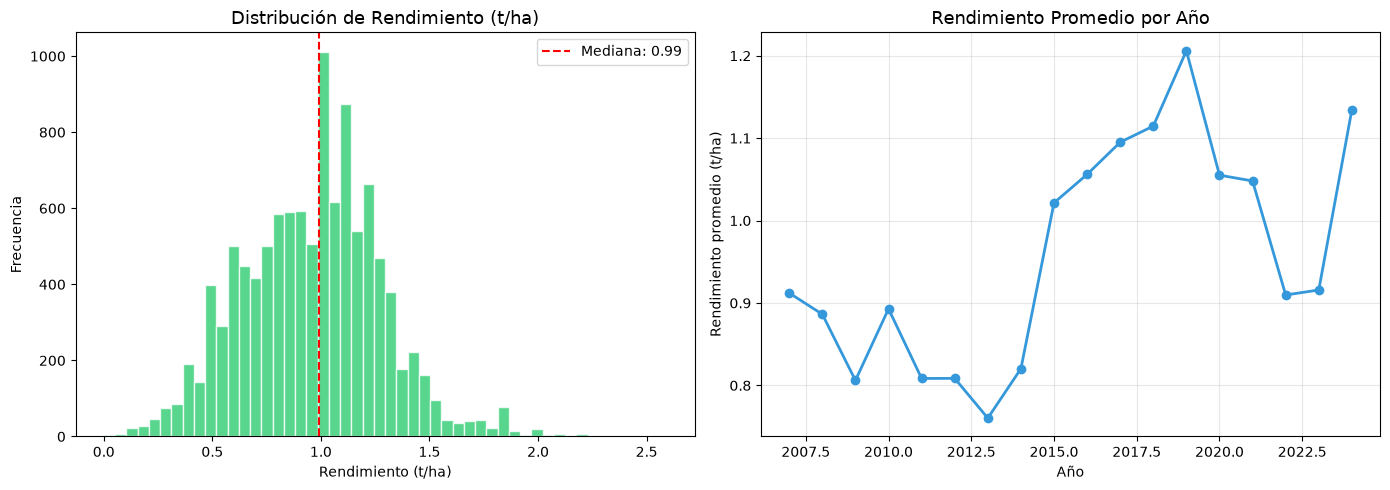

In [4]:
# Estadísticas descriptivas del target
print('=== Estadísticas de rendimiento_t_ha ===')
print(df['rendimiento_t_ha'].describe().round(4))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma de rendimiento
axes[0].hist(df['rendimiento_t_ha'].dropna(), bins=50, color='#2ecc71', edgecolor='white', alpha=0.8)
axes[0].set_title('Distribución de Rendimiento (t/ha)', fontsize=13)
axes[0].set_xlabel('Rendimiento (t/ha)')
axes[0].set_ylabel('Frecuencia')
axes[0].axvline(df['rendimiento_t_ha'].median(), color='red', linestyle='--', label=f'Mediana: {df["rendimiento_t_ha"].median():.2f}')
axes[0].legend()

# Evolución temporal promedio
evol = df.groupby('anio')['rendimiento_t_ha'].mean()
axes[1].plot(evol.index, evol.values, 'o-', color='#3498db', linewidth=2, markersize=6)
axes[1].set_title('Rendimiento Promedio por Año', fontsize=13)
axes[1].set_xlabel('Año')
axes[1].set_ylabel('Rendimiento promedio (t/ha)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 4. 🔄 ETL v3: Normalización Inteligente

Normaliza las 42 features numéricas con Z-score, **preservando** las columnas de identificación:
- `departamento`, `municipio`, `cultivo`, `anio`, `fuente_eva`, `split`

In [5]:
!python3 src/etl/etl_normalizacion.py


🔄 ETL v3 - Normalización INTELIGENTE (Identificadores Preservados)

──────────────────────────────────────────────────────────────────────

Cargando data/processed/model_mart_cafe.csv...


✓ 10973 filas × 48 columnas
  Variables identificadores (no normalizar): 6
  Variables numéricas (normalizar): 42
  Variables categóricas (mantener): 0

Limpiando datos...


  ✓ Imputando NULL...


  ✓ Limpieza completada

Calculando estadísticas...


  ✓ 42 variables con parámetros

Normalizando features...


  ✓ 42 features normalizadas

Guardando...


  ✓ data/processed/etl_normalized_v3/model_mart_cafe.csv
  ✓ Reporte guardado

✅ CAFE completado

✅ RESUMEN FINAL

CAFE:
  Entrada:           10973 filas
  Salida:            10973 filas
  Identificadores:   6 (sin normalizar)
  Features normalizadas: 42
  ✅ Listo para entrenar modelos ML

📁 Archivos generados: data/processed/etl_normalized_v3/



## 5. 📏 Evaluación de Heurísticas Base (Baselines)

Medimos el error de dos estrategias naive:
- **B1:** Copiar rendimiento del año anterior (lag-1)
- **B2:** Promedio de los últimos 3 años

Estos baselines son la **referencia mínima** que el modelo ML debe superar.

In [6]:
!python3 src/models/01_eval_baselines.py

print('\n=== Resumen de Baselines ===')
try:
    res_b = pd.read_csv('reports/tables/resultados_baselines_cafe.csv')
    display(res_b.groupby('Modelo')[['MAE', 'RMSE', 'R2']].mean().round(4))
except FileNotFoundError:
    print('Archivo de resultados no encontrado.')

=== Evaluación de Baselines (Heurísticas) para CAFE ===



--- Baseline 1: Rendimiento del año anterior ---
        MAE   RMSE     R2    MAPE    N
Año                                   
2019  0.324  0.389 -1.948  28.632  579
2020  0.200  0.323 -0.248  35.965  619
2021  0.231  0.314 -0.991  23.007  625
2022  0.209  0.290 -0.005  35.933  631
2023  0.173  0.274  0.329  24.864  625
2024  0.248  0.311  0.367  21.837  623

Promedio B1 MAE : 0.231 t/ha
Promedio B1 RMSE: 0.317 t/ha

--- Baseline 2: Promedio de los últimos 3 años ---


        MAE   RMSE     R2    MAPE    N
Año                                   
2019  0.267  0.318 -0.994  23.856  577
2020  0.262  0.352 -0.504  41.605  579
2021  0.196  0.248 -0.271  20.332  579
2022  0.270  0.334 -0.347  44.867  619
2023  0.226  0.297  0.215  36.791  620
2024  0.236  0.319  0.335  22.030  623

Promedio B2 MAE : 0.243 t/ha
Promedio B2 RMSE: 0.311 t/ha



✓ Resultados guardados en reports/tables/resultados_baselines_cafe.csv



=== Resumen de Baselines ===


,MAE,RMSE,R2
Modelo,,,
Baseline 1 (t-1),0.231,0.3169,-0.4161
Baseline 2 (media 3y),0.243,0.3113,-0.2609


## 6. 🤖 Entrenamiento ML: CatBoost + Ablation Study

Entrenamos un CatBoostRegressor con esquema **rolling-origin temporal** (train < año, test = año).

### Fases del Ablation Study
| Fase | Features añadidas |
|------|-------------------|
| A | Lags temporales + target encoding |
| B | + Variables climáticas |
| C | + Variables de suelo |
| D | + Aptitud UPRA |
| E | + Crédito FINAGRO |
| F | + Precio internacional |

### Estrategia Híbrida
```
Predicción = α × ML_CatBoost + (1-α) × Baseline_lag1
```
Se busca el α óptimo que minimiza el MAE promedio sobre todos los años de backtest.

In [7]:
!python3 src/models/02_train_ml.py

=== Ablation Study: CatBoost Regressor (CAFE) ===


Enriqueciendo features (target encoding, cambio de área)...



── Buscando alpha óptimo de blending (ML vs Baseline) ──


  α=0.0 (  puro Baseline): MAE=0.2310


  α=0.1 (      blend 10%): MAE=0.2262


...

  Baseline MAE : 0.2310 t/ha
  ML Puro MAE  : 0.2071 t/ha
  Híbrido MAE  : 0.2056 t/ha  ✅ (+11.0% vs baseline)
  Híbrido R²   : -0.0687

Modelo E (29 features disponibles)...


  Baseline MAE : 0.2310 t/ha
  ML Puro MAE  : 0.2115 t/ha
  Híbrido MAE  : 0.2093 t/ha  ✅ (+9.4% vs baseline)
  Híbrido R²   : -0.0833

Modelo F (29 features disponibles)...


  Baseline MAE : 0.2310 t/ha
  ML Puro MAE  : 0.2115 t/ha
  Híbrido MAE  : 0.2093 t/ha  ✅ (+9.4% vs baseline)
  Híbrido R²   : -0.0833

--- Feature Importance (Top 15 en Modelo F, 2024) ---


rendimiento_lag_1                32.43
municipio_rend_historico         16.73
rendimiento_lag_2                 9.22
score_confiabilidad               5.63
rendimiento_lag_3                 5.16
media_rendimiento_3y              4.58
tendencia_rendimiento_3y          3.79
ratio_area_sembrada_cosechada     3.78
depto_rend_historico              3.65
variabilidad_rendimiento_3y       2.91
cambio_area_pct                   2.55
produccion_lag_1                  1.51
area_cosechada_lag_1              1.49
area_sembrada_lag_1               1.40
log_credito_total                 0.50



✓ Resultados guardados en reports/tables/resultados_ml_ablation_cafe.csv


In [8]:
# Ver resultados del Ablation Study
try:
    res_ml = pd.read_csv('reports/tables/resultados_ml_ablation_cafe.csv')
    print('=== Resumen por Fase y Tipo ===')
    resumen = res_ml.groupby(['Fase', 'Tipo'])[['MAE', 'RMSE', 'R2']].mean().round(4)
    display(resumen)
except FileNotFoundError:
    print('Ejecute primero la celda de entrenamiento.')

=== Resumen por Fase y Tipo ===


MAE    RMSE      R2
Fase Tipo                            
A    Baseline  0.2310  0.3169 -0.4161
     Híbrido   0.2048  0.2829 -0.0591
     ML_Puro   0.2068  0.2831 -0.0396
B    Baseline  0.2310  0.3169 -0.4161
     Híbrido   0.2048  0.2829 -0.0591
     ML_Puro   0.2068  0.2831 -0.0396
C    Baseline  0.2310  0.3169 -0.4161
     Híbrido   0.2056  0.2839 -0.0687
     ML_Puro   0.2071  0.2838 -0.0470
D    Baseline  0.2310  0.3169 -0.4161
     Híbrido   0.2056  0.2839 -0.0687
     ML_Puro   0.2071  0.2838 -0.0470
E    Baseline  0.2310  0.3169 -0.4161
     Híbrido   0.2093  0.2874 -0.0833
     ML_Puro   0.2115  0.2879 -0.0648
F    Baseline  0.2310  0.3169 -0.4161
     Híbrido   0.2093  0.2874 -0.0833
     ML_Puro   0.2115  0.2879 -0.0648

## 7. 📈 Visualización de Resultados

Traceback (most recent call last):
  File "/home/william/Documentos/proyecto IngDatos/src/models/03_plot_results.py", line 10, in <module>
    import matplotlib.pyplot as plt
  File "/home/william/.local/lib/python3.12/site-packages/matplotlib/__init__.py", line 1289, in <module>
    rcParams['backend'] = os.environ.get('MPLBACKEND')
    ~~~~~~~~^^^^^^^^^^^
  File "/home/william/.local/lib/python3.12/site-packages/matplotlib/__init__.py", line 781, in __setitem__
    raise ValueError(f"Key {key}: {ve}") from None
ValueError: Key backend: 'module://matplotlib_inline.backend_inline' is not a valid value for backend; supported values are ['gtk3agg', 'gtk3cairo', 'gtk4agg', 'gtk4cairo', 'macosx', 'nbagg', 'notebook', 'qtagg', 'qtcairo', 'qt5agg', 'qt5cairo', 'tkagg', 'tkcairo', 'webagg', 'wx', 'wxagg', 'wxcairo', 'agg', 'cairo', 'pdf', 'pgf', 'ps', 'svg', 'template']


Traceback (most recent call last):
  File "/home/william/Documentos/proyecto IngDatos/src/models/07_plot_regression.py", line 10, in <module>
    import matplotlib.pyplot as plt
  File "/home/william/.local/lib/python3.12/site-packages/matplotlib/__init__.py", line 1289, in <module>
    rcParams['backend'] = os.environ.get('MPLBACKEND')
    ~~~~~~~~^^^^^^^^^^^
  File "/home/william/.local/lib/python3.12/site-packages/matplotlib/__init__.py", line 781, in __setitem__
    raise ValueError(f"Key {key}: {ve}") from None
ValueError: Key backend: 'module://matplotlib_inline.backend_inline' is not a valid value for backend; supported values are ['gtk3agg', 'gtk3cairo', 'gtk4agg', 'gtk4cairo', 'macosx', 'nbagg', 'notebook', 'qtagg', 'qtcairo', 'qt5agg', 'qt5cairo', 'tkagg', 'tkcairo', 'webagg', 'wx', 'wxagg', 'wxcairo', 'agg', 'cairo', 'pdf', 'pgf', 'ps', 'svg', 'template']



--- mae_comparative_cafe.png ---


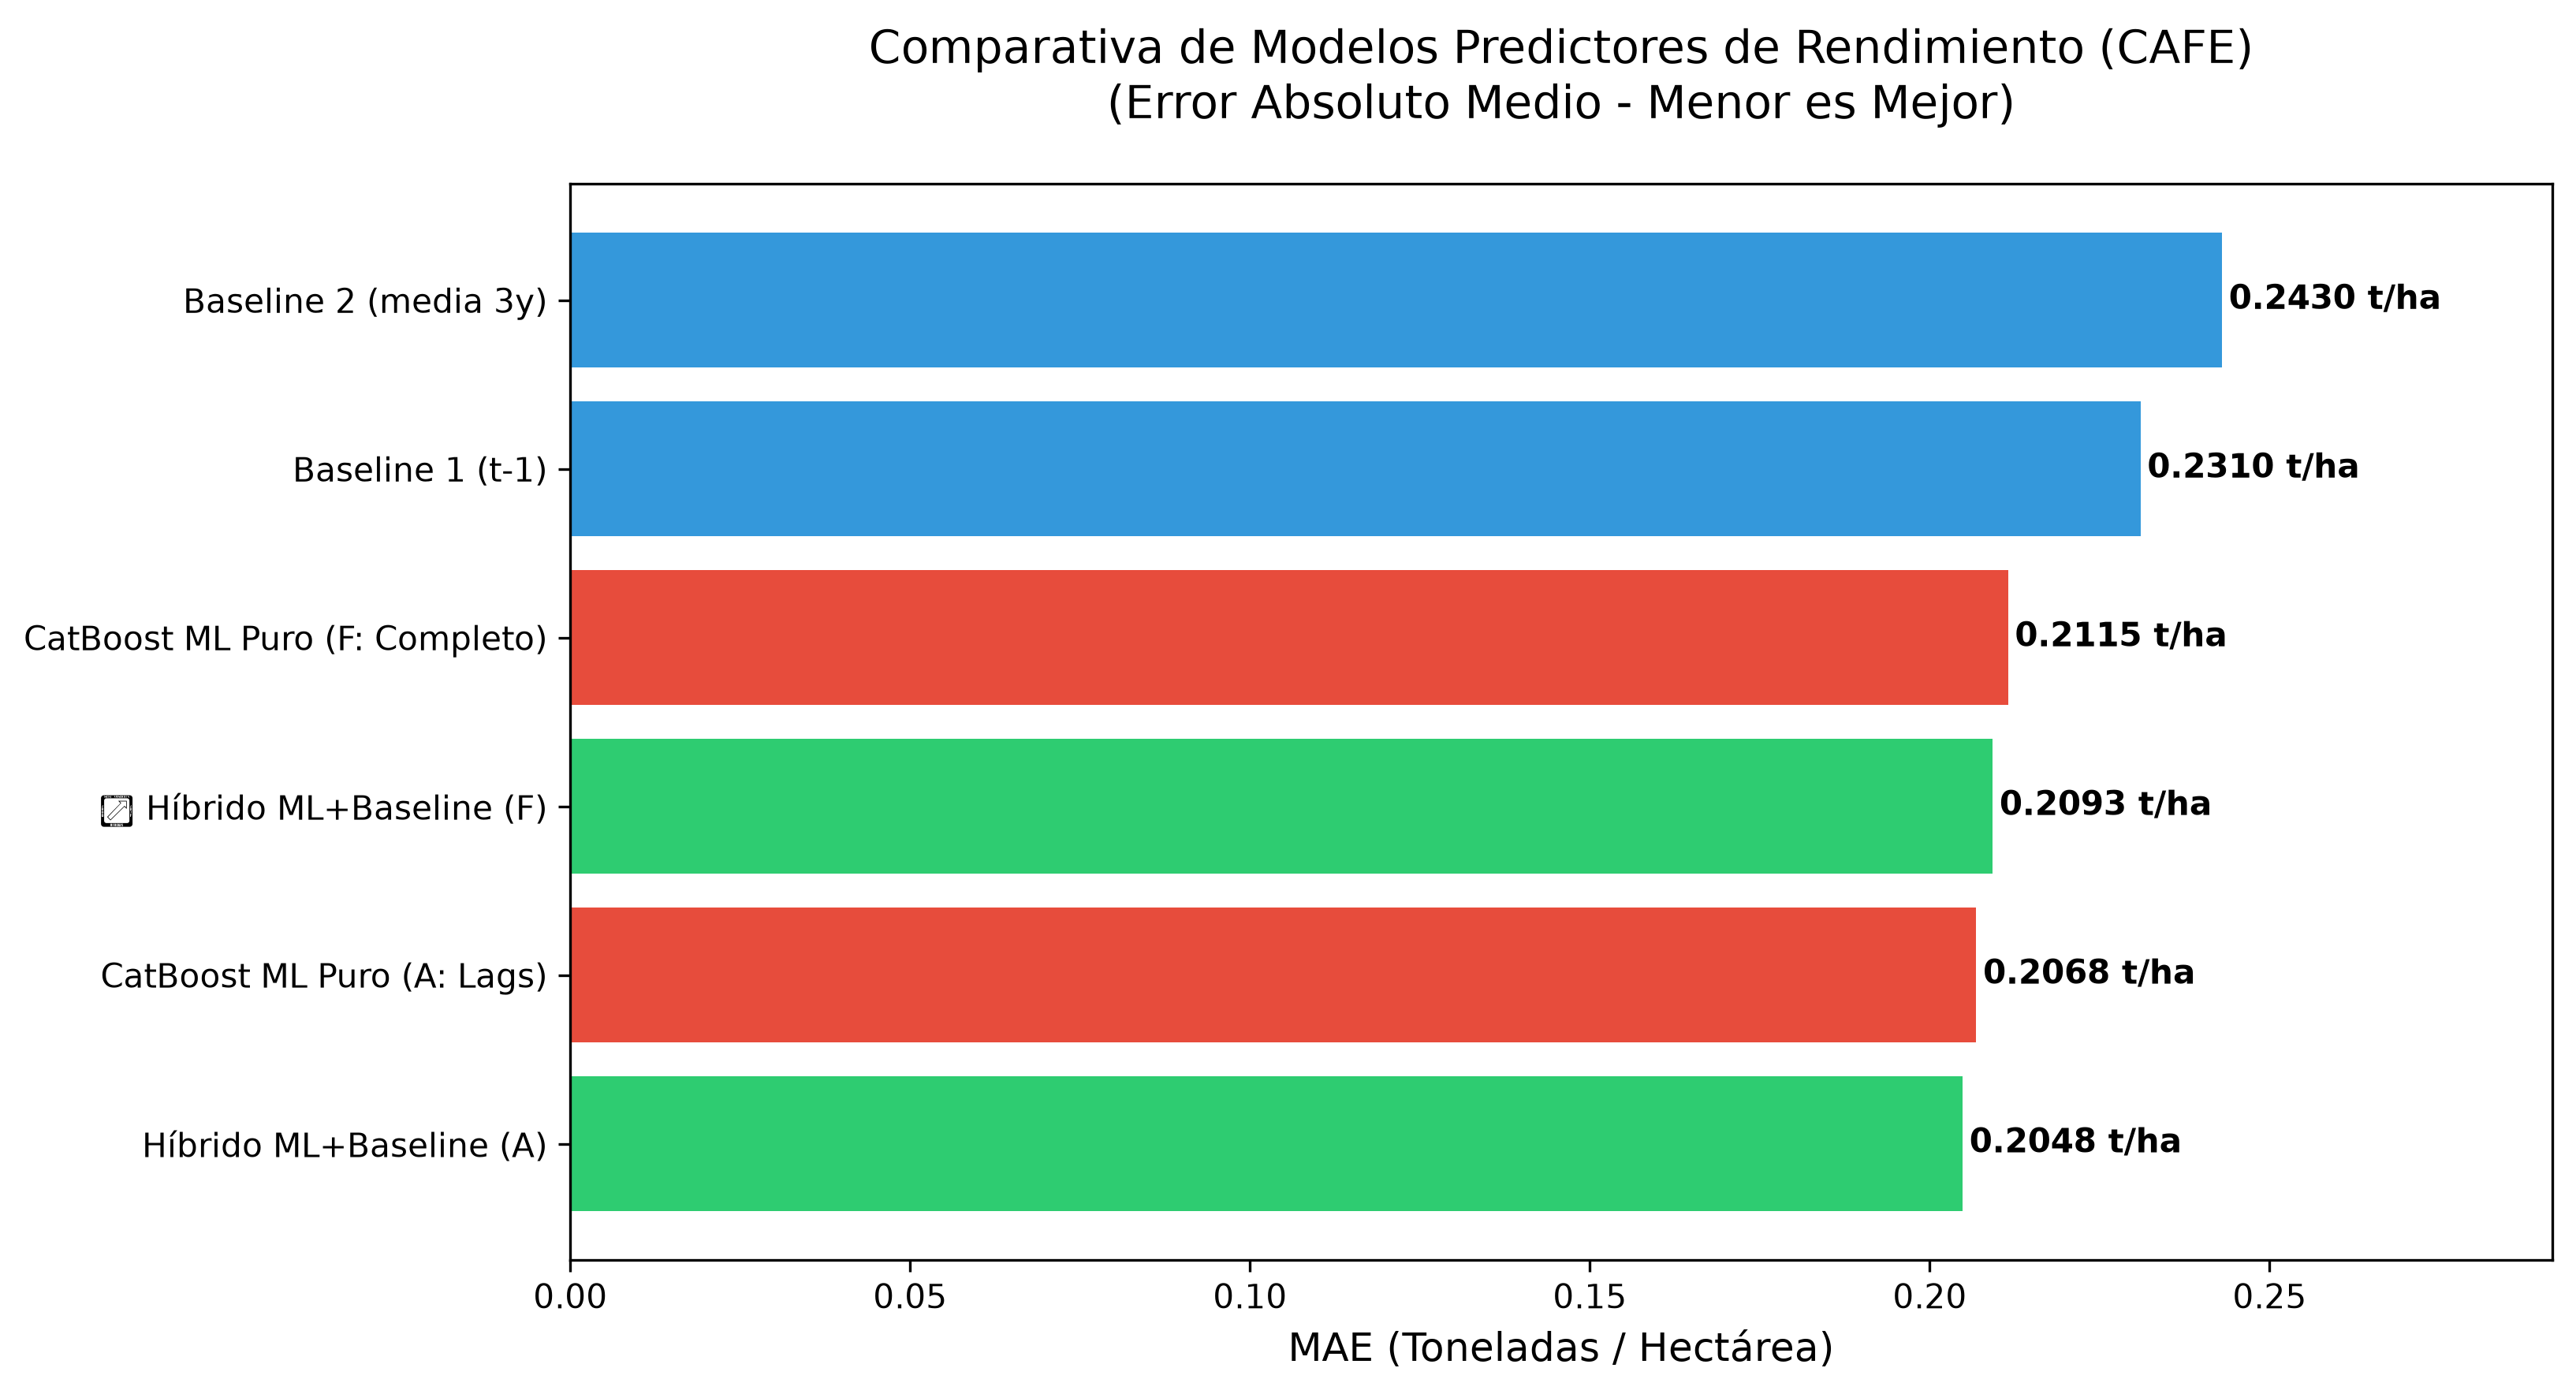


--- feature_importance_cafe.png ---


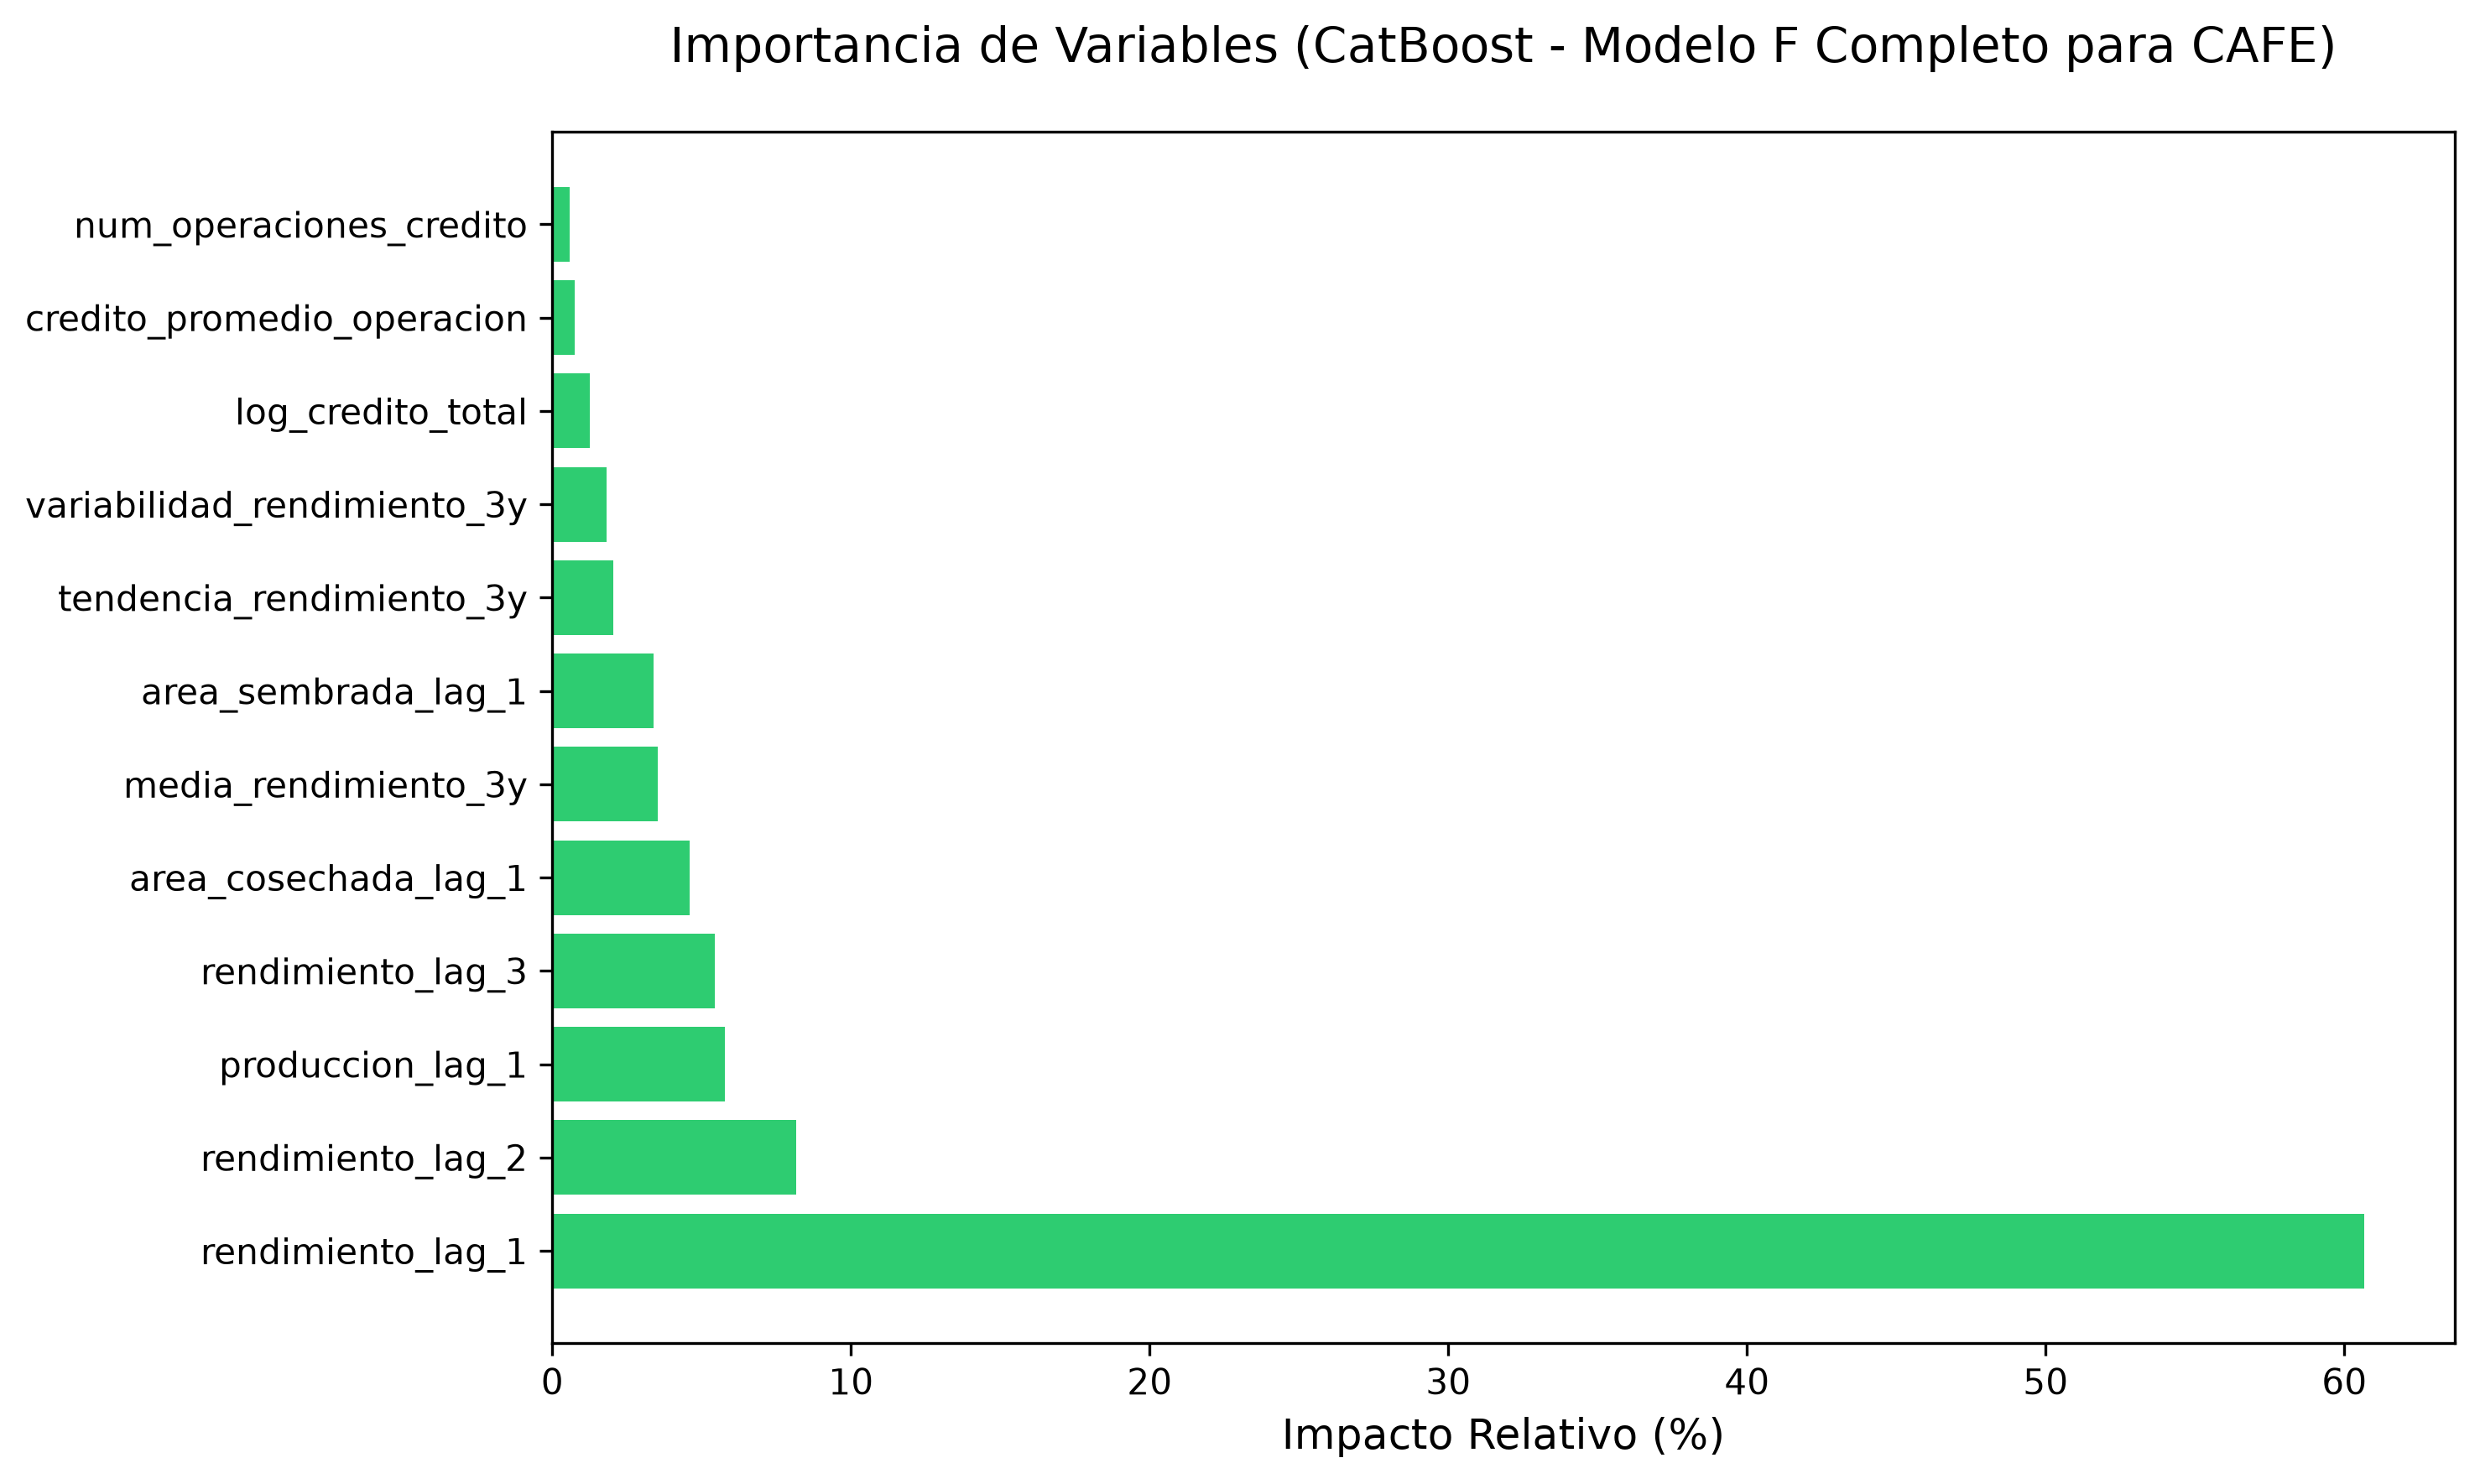

In [9]:
!python3 src/models/03_plot_results.py
!python3 src/models/07_plot_regression.py

from IPython.display import Image, display as ipy_display
import os

for img in ['mae_comparative_cafe.png', 'feature_importance_cafe.png', 'regression_real_vs_pred_cafe.png']:
    path = f'reports/figures/{img}'
    if os.path.exists(path):
        print(f'\n--- {img} ---')
        ipy_display(Image(filename=path))

## 8. 💰 Análisis de Rentabilidad

In [10]:
!python3 src/models/05_rentabilidad.py

from IPython.display import Image, display as ipy_display
import os

for img in ['rentabilidad_cafe.png', 'top_municipios_cafe.png']:
    path = f'reports/figures/{img}'
    if os.path.exists(path):
        print(f'\n--- {img} ---')
        ipy_display(Image(filename=path))

Traceback (most recent call last):
  File "/home/william/Documentos/proyecto IngDatos/src/models/05_rentabilidad.py", line 5, in <module>
    import matplotlib.pyplot as plt
  File "/home/william/.local/lib/python3.12/site-packages/matplotlib/__init__.py", line 1289, in <module>
    rcParams['backend'] = os.environ.get('MPLBACKEND')
    ~~~~~~~~^^^^^^^^^^^
  File "/home/william/.local/lib/python3.12/site-packages/matplotlib/__init__.py", line 781, in __setitem__
    raise ValueError(f"Key {key}: {ve}") from None
ValueError: Key backend: 'module://matplotlib_inline.backend_inline' is not a valid value for backend; supported values are ['gtk3agg', 'gtk3cairo', 'gtk4agg', 'gtk4cairo', 'macosx', 'nbagg', 'notebook', 'qtagg', 'qtcairo', 'qt5agg', 'qt5cairo', 'tkagg', 'tkcairo', 'webagg', 'wx', 'wxagg', 'wxcairo', 'agg', 'cairo', 'pdf', 'pgf', 'ps', 'svg', 'template']


## 9. 🔮 Forecast a Futuro (2025-2029) + Probabilidad de Éxito

Simulación de **1,000 escenarios** climáticos y financieros para los próximos 5 años.

Para cada municipio se calcula:
- **Rendimiento proyectado** (t/ha)
- **Ingreso estimado** (COP/ha)
- **Probabilidad de Éxito** = P(ingreso > línea base) usando CDF con σ = 0.15

Traceback (most recent call last):
  File "/home/william/Documentos/proyecto IngDatos/src/models/06_forecast_futuro.py", line 10, in <module>
    import matplotlib.pyplot as plt
  File "/home/william/.local/lib/python3.12/site-packages/matplotlib/__init__.py", line 1289, in <module>
    rcParams['backend'] = os.environ.get('MPLBACKEND')
    ~~~~~~~~^^^^^^^^^^^
  File "/home/william/.local/lib/python3.12/site-packages/matplotlib/__init__.py", line 781, in __setitem__
    raise ValueError(f"Key {key}: {ve}") from None
ValueError: Key backend: 'module://matplotlib_inline.backend_inline' is not a valid value for backend; supported values are ['gtk3agg', 'gtk3cairo', 'gtk4agg', 'gtk4cairo', 'macosx', 'nbagg', 'notebook', 'qtagg', 'qtcairo', 'qt5agg', 'qt5cairo', 'tkagg', 'tkcairo', 'webagg', 'wx', 'wxagg', 'wxcairo', 'agg', 'cairo', 'pdf', 'pgf', 'ps', 'svg', 'template']



--- forecast_ingresos_cafe.png ---


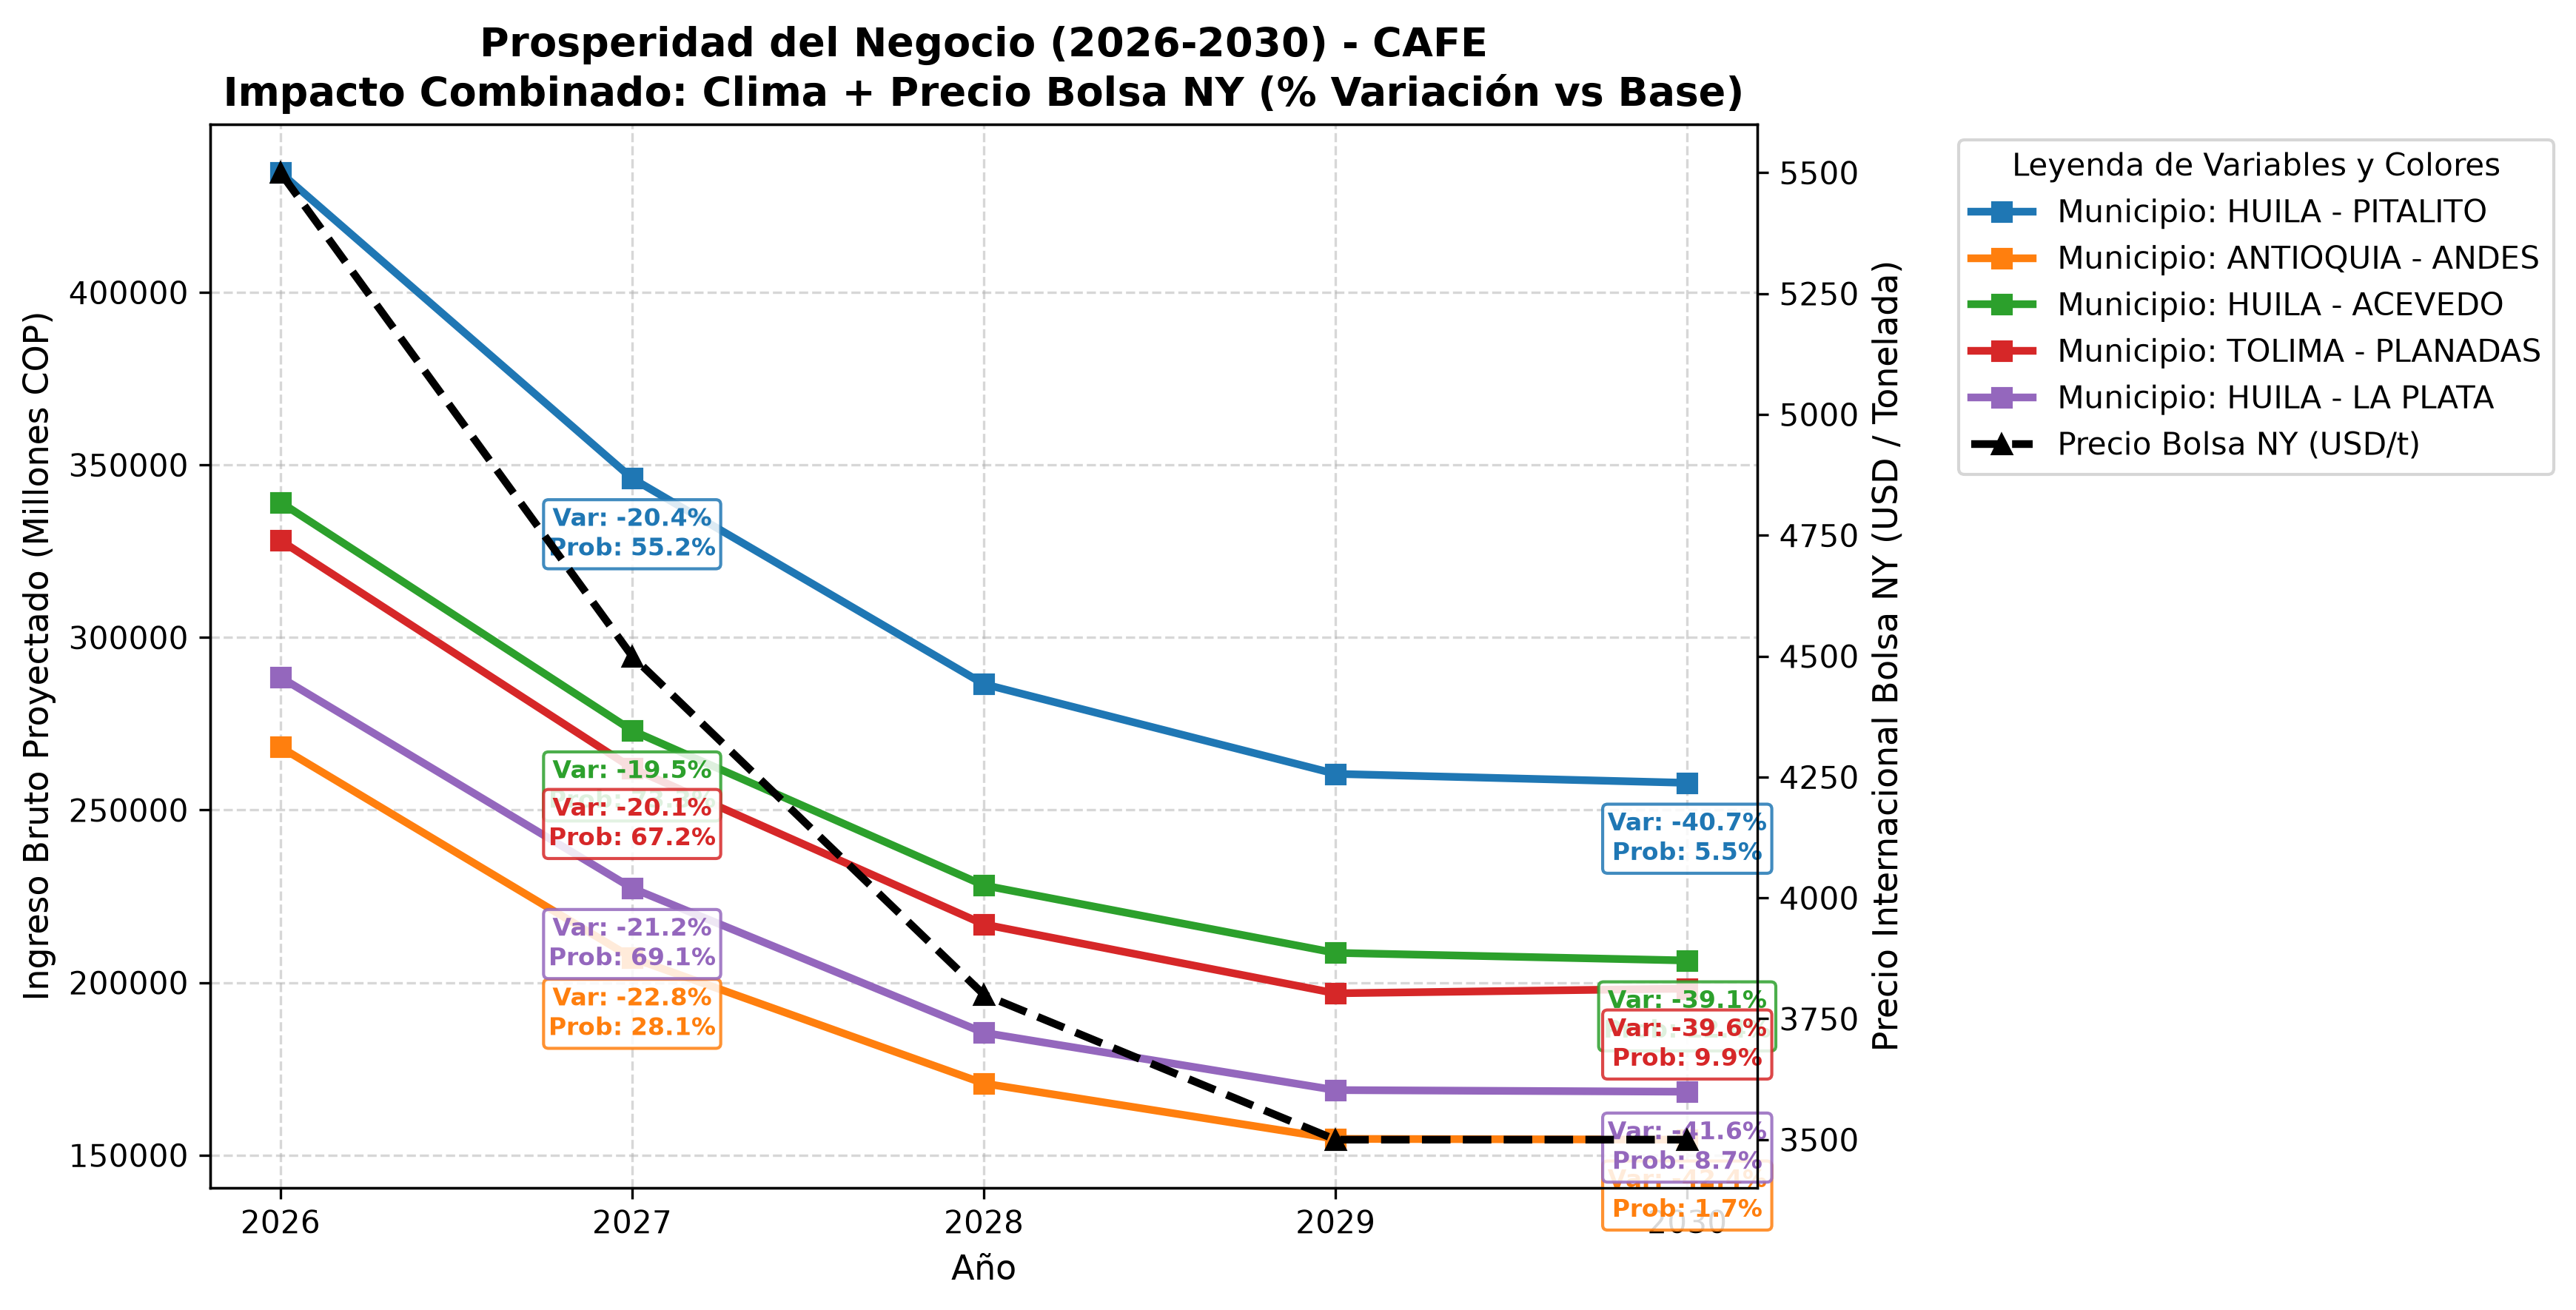


--- forecast_probabilidades_cafe.png ---


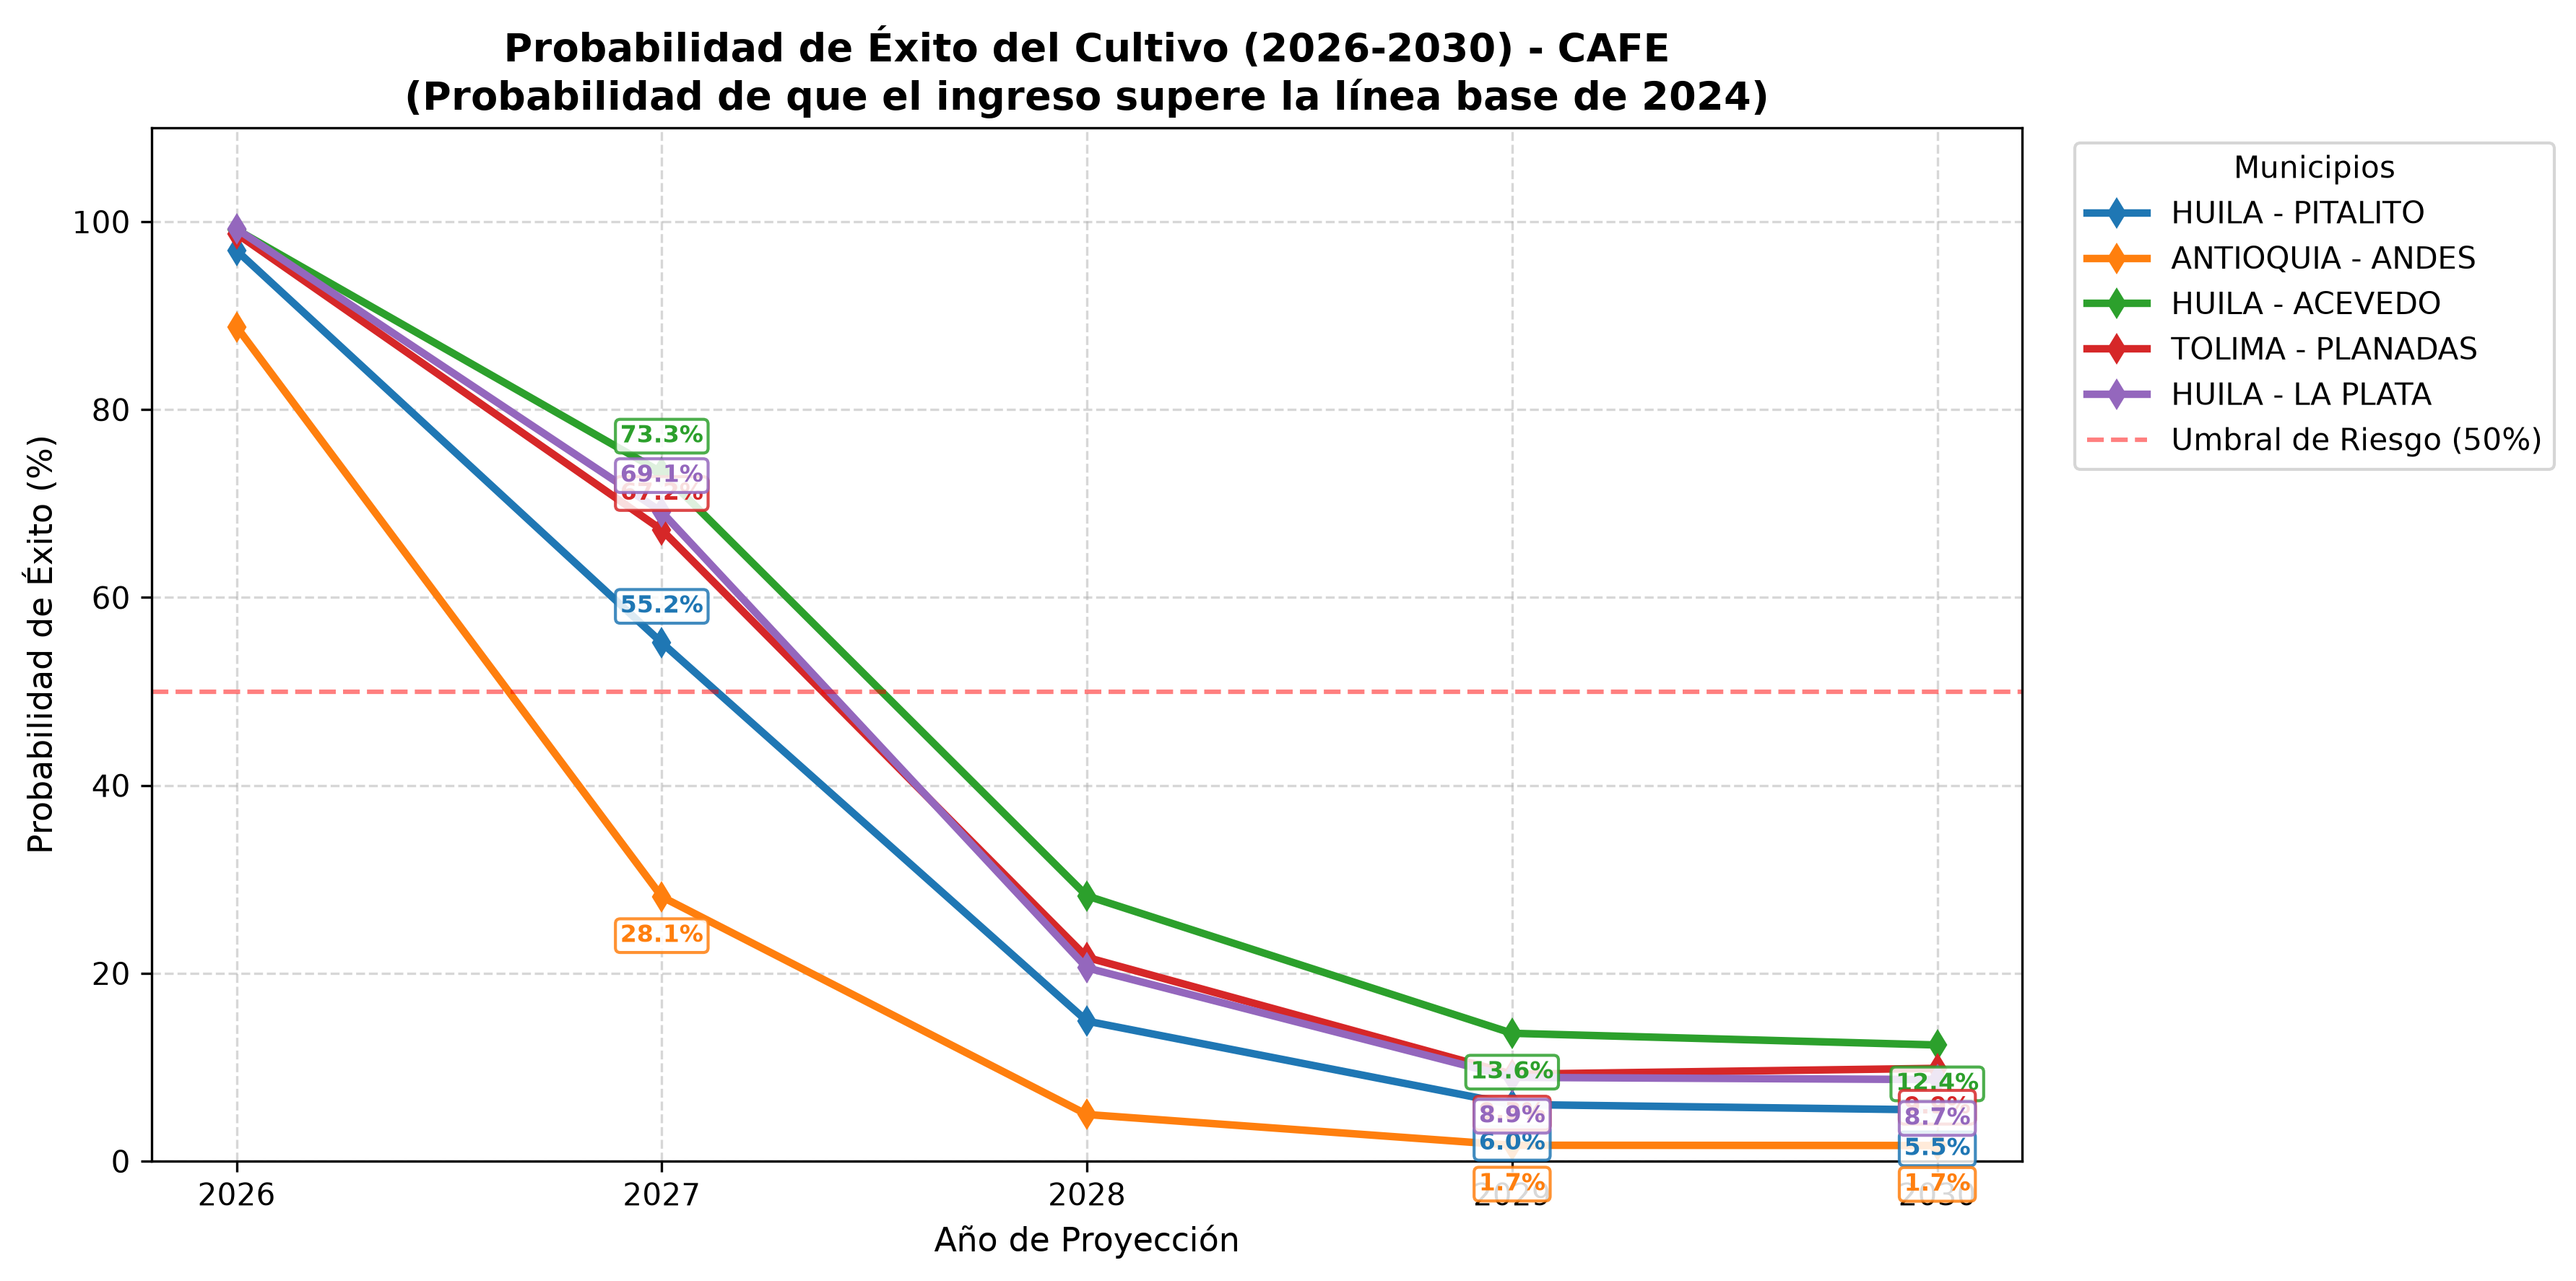

In [11]:
!python3 src/models/06_forecast_futuro.py

from IPython.display import Image, display as ipy_display
import os

for img in ['forecast_ingresos_cafe.png', 'forecast_probabilidades_cafe.png']:
    path = f'reports/figures/{img}'
    if os.path.exists(path):
        print(f'\n--- {img} ---')
        ipy_display(Image(filename=path))

## 10. 📋 Resumen de Artefactos Generados
Listado de todos los archivos producidos por el pipeline.

In [12]:
import os

print('=== 📊 Figuras (reports/figures/) ===')
for f in sorted(os.listdir('reports/figures')):
    size = os.path.getsize(f'reports/figures/{f}') / 1024
    print(f'  {f:50s} ({size:.1f} KB)')

print('\n=== 📋 Tablas (reports/tables/) ===')
for f in sorted(os.listdir('reports/tables')):
    size = os.path.getsize(f'reports/tables/{f}') / 1024
    print(f'  {f:50s} ({size:.1f} KB)')

print('\n✅ Pipeline completado exitosamente.')

=== 📊 Figuras (reports/figures/) ===
  feature_importance_cafe.png                        (170.4 KB)
  forecast_ingresos_cafe.png                         (512.0 KB)
  forecast_probabilidades_cafe.png                   (389.8 KB)
  forecast_rendimiento_cafe.png                      (357.3 KB)
  mae_comparative_cafe.png                           (190.4 KB)
  regression_curve_cafe.png                          (560.1 KB)
  rentabilidad_top_municipios_cafe.png               (361.5 KB)

=== 📋 Tablas (reports/tables/) ===


  forecast_cafe.csv                                  (3.4 KB)
  proyeccion_negocio_cafe.csv                        (46.5 KB)
  resultados_baselines_cafe.csv                      (1.3 KB)
  resultados_ml_ablation_cafe.csv                    (8.4 KB)
  resultados_rigorous_cafe.csv                       (0.8 KB)

✅ Pipeline completado exitosamente.


---
## 📚 Documentación del Proyecto

| Documento | Contenido |
|-----------|----------|
| `docs/01_Diccionario_y_Arquitectura.md` | Arquitectura de datos y diccionario |
| `docs/02_Trazabilidad_Variables_Modelos.md` | Variables usadas en cada modelo |
| `docs/03_ETL_CAFE_SIN_LEAKAGE_step_1.md` | **ETL Paso 1:** Extracción sin data leakage |
| `docs/04_ETL_EXPLICACION_step_2.md` | **ETL Paso 2:** Feature engineering → `dataset_cafe_ml_ready.csv` |
| `docs/05_ETL_NORMALIZACION.md` | Normalización Z-score |
| `docs/06_FAQ_DATOS_VACIOS.md` | Manejo de datos faltantes |
| `docs/07_TRAIN_ML_RIGOROUS_GUIDE.md` | Guía de entrenamiento riguroso |
| `docs/08_CAFE_EXECUTIVE_SUMMARY.md` | Resumen ejecutivo |
| `docs/09_CAFE_ONLY_README.md` | README específico del cultivo de café |
| `docs/10_TRAINING_PORTABLE_README.md` | Guía portátil de entrenamiento |